# 03 — Exploratory Survival Analysis

This notebook performs exploratory survival analysis on the cleaned TCGA-BRCA cohort.

The goals are to:

- inspect the cleaned survival dataset
- summarize event and censoring patterns
- visualize follow-up time
- estimate the overall Kaplan–Meier survival curve
- compare survival across stage groups

These exploratory results provide a baseline understanding of the cohort before fitting parametric or Bayesian nonparametric survival models.

In [3]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Load cleaned survival dataset
from pathlib import Path

processed_path = Path("../data/processed/tcga_brca_survival_cleaned.csv")
df = pd.read_csv(processed_path)

# Ensure event is integer
df["event"] = df["event"].astype(int)

df["event"].value_counts()

print(df.shape)
df.head()

(1095, 9)


,case_id,primary_diagnosis,ajcc_pathologic_stage,demographic.gender,demographic.race,age_at_diagnosis_years,event,time_days,stage_simple
0,001cef41-ff86-4d3f-a140-a647ac4b10a1,"Infiltrating duct carcinoma, NOS",Stage IA,female,white,60.996578,0,337.0,Stage I
1,0045349c-69d9-4306-a403-c9c1fa836644,Adenoid cystic carcinoma,Stage I,female,white,70.726899,0,259.0,Stage I
2,00807dae-9f4a-4fd1-aac2-82eb11bf2afb,Apocrine adenocarcinoma,Stage IIB,female,white,50.225873,0,3102.0,Stage II
3,00a2d166-78c9-4687-a195-3d6315c27574,"Infiltrating duct carcinoma, NOS",Stage IIA,female,white,56.709103,0,5.0,Stage II
4,00b11ca8-8540-4a3d-b602-ec754b00230b,"Lobular carcinoma, NOS",Stage IA,female,white,61.593429,0,759.0,Stage I


In [4]:
# Basic cohort summary
print("Number of patients:", len(df))
print()

print("Event distribution:")
print(df["event"].value_counts())
print()

print("Stage distribution:")
print(df["stage_simple"].value_counts(dropna=False))

Number of patients: 1095

Event distribution:
event
0    944
1    151
Name: count, dtype: int64

Stage distribution:
stage_simple
Stage II     620
Stage III    248
Stage I      183
NaN           24
Stage IV      20
Name: count, dtype: int64


In [5]:
# Survival time distribution
df["time_days"].describe()

count    1095.000000
mean     1234.346119
std      1191.475805
min         0.000000
25%       446.000000
50%       825.000000
75%      1673.000000
max      8605.000000
Name: time_days, dtype: float64

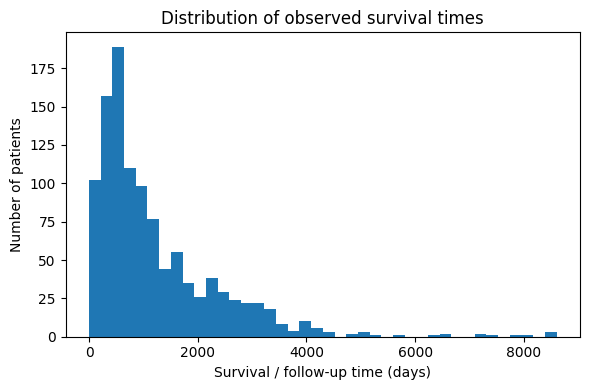

In [6]:
# Histogram of follow-up / survival time
plt.figure(figsize=(6,4))

plt.hist(df["time_days"], bins=40)
plt.xlabel("Survival / follow-up time (days)")
plt.ylabel("Number of patients")
plt.title("Distribution of observed survival times")

plt.tight_layout()
plt.show()

- Strong right skew → typical for survival times
- Many patients observed within 0–1500 days
- Long right tail → long-term survivors / long follow-up
- Small mass at 0 days → diagnosis with immediate censoring or death (common in clinical datasets)

All Looks good! Time to do some KM estimates

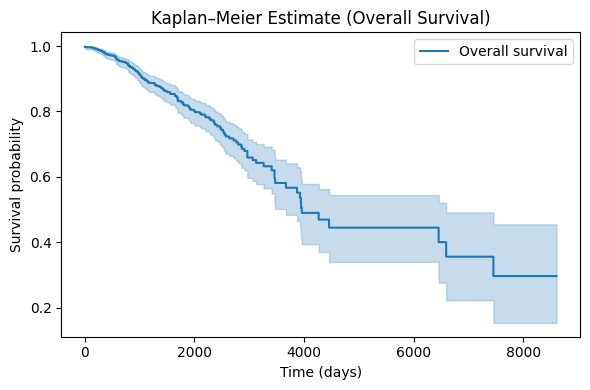

In [7]:
# Kaplan–Meier estimate (overall survival)
kmf = KaplanMeierFitter()

T = df["time_days"]
E = df["event"]

plt.figure(figsize=(6,4))

kmf.fit(T, event_observed=E, label="Overall survival")
kmf.plot_survival_function()

plt.xlabel("Time (days)")
plt.ylabel("Survival probability")
plt.title("Kaplan–Meier Estimate (Overall Survival)")

plt.tight_layout()
plt.show()

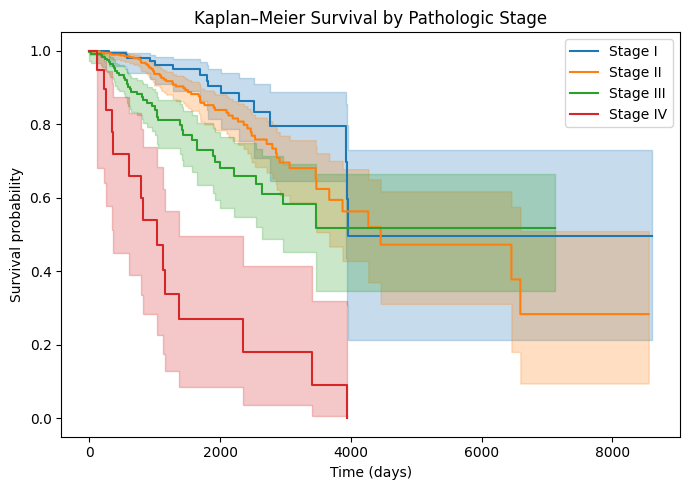

In [8]:
# Kaplan–Meier curves by stage
plt.figure(figsize=(7,5))

for stage, subset in df.dropna(subset=["stage_simple"]).groupby("stage_simple"):
    
    kmf.fit(
        subset["time_days"],
        event_observed=subset["event"],
        label=stage
    )
    
    kmf.plot_survival_function()

plt.xlabel("Time (days)")
plt.ylabel("Survival probability")
plt.title("Kaplan–Meier Survival by Pathologic Stage")

plt.tight_layout()
plt.show()

In [9]:
# Log-rank test: Stage I vs Stage III (example comparison)
stage_I = df[df["stage_simple"] == "Stage I"]
stage_III = df[df["stage_simple"] == "Stage III"]

results = logrank_test(
    stage_I["time_days"],
    stage_III["time_days"],
    event_observed_A=stage_I["event"],
    event_observed_B=stage_III["event"]
)

print(results.summary)

   test_statistic         p   -log2(p)
0       13.867114  0.000196  12.315374


Given the test statistic, we can reject the null hypothesis that S1 and S3 have identical survival distributions, which is a good sanity check

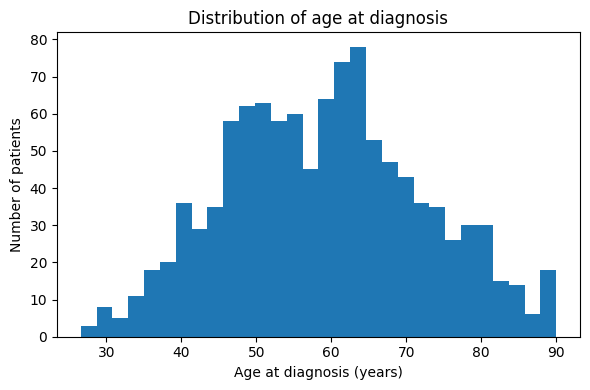

In [10]:
# Age distribution
plt.figure(figsize=(6,4))

plt.hist(df["age_at_diagnosis_years"].dropna(), bins=30)
plt.xlabel("Age at diagnosis (years)")
plt.ylabel("Number of patients")
plt.title("Distribution of age at diagnosis")

plt.tight_layout()
plt.show()

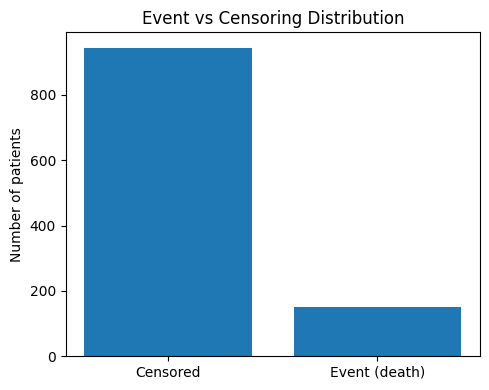

event
0    944
1    151
Name: count, dtype: int64


In [11]:
# Event vs censoring counts
event_counts = df["event"].value_counts().sort_index()

plt.figure(figsize=(5,4))

plt.bar(["Censored", "Event (death)"], event_counts)
plt.ylabel("Number of patients")
plt.title("Event vs Censoring Distribution")

plt.tight_layout()
plt.show()

print(event_counts)